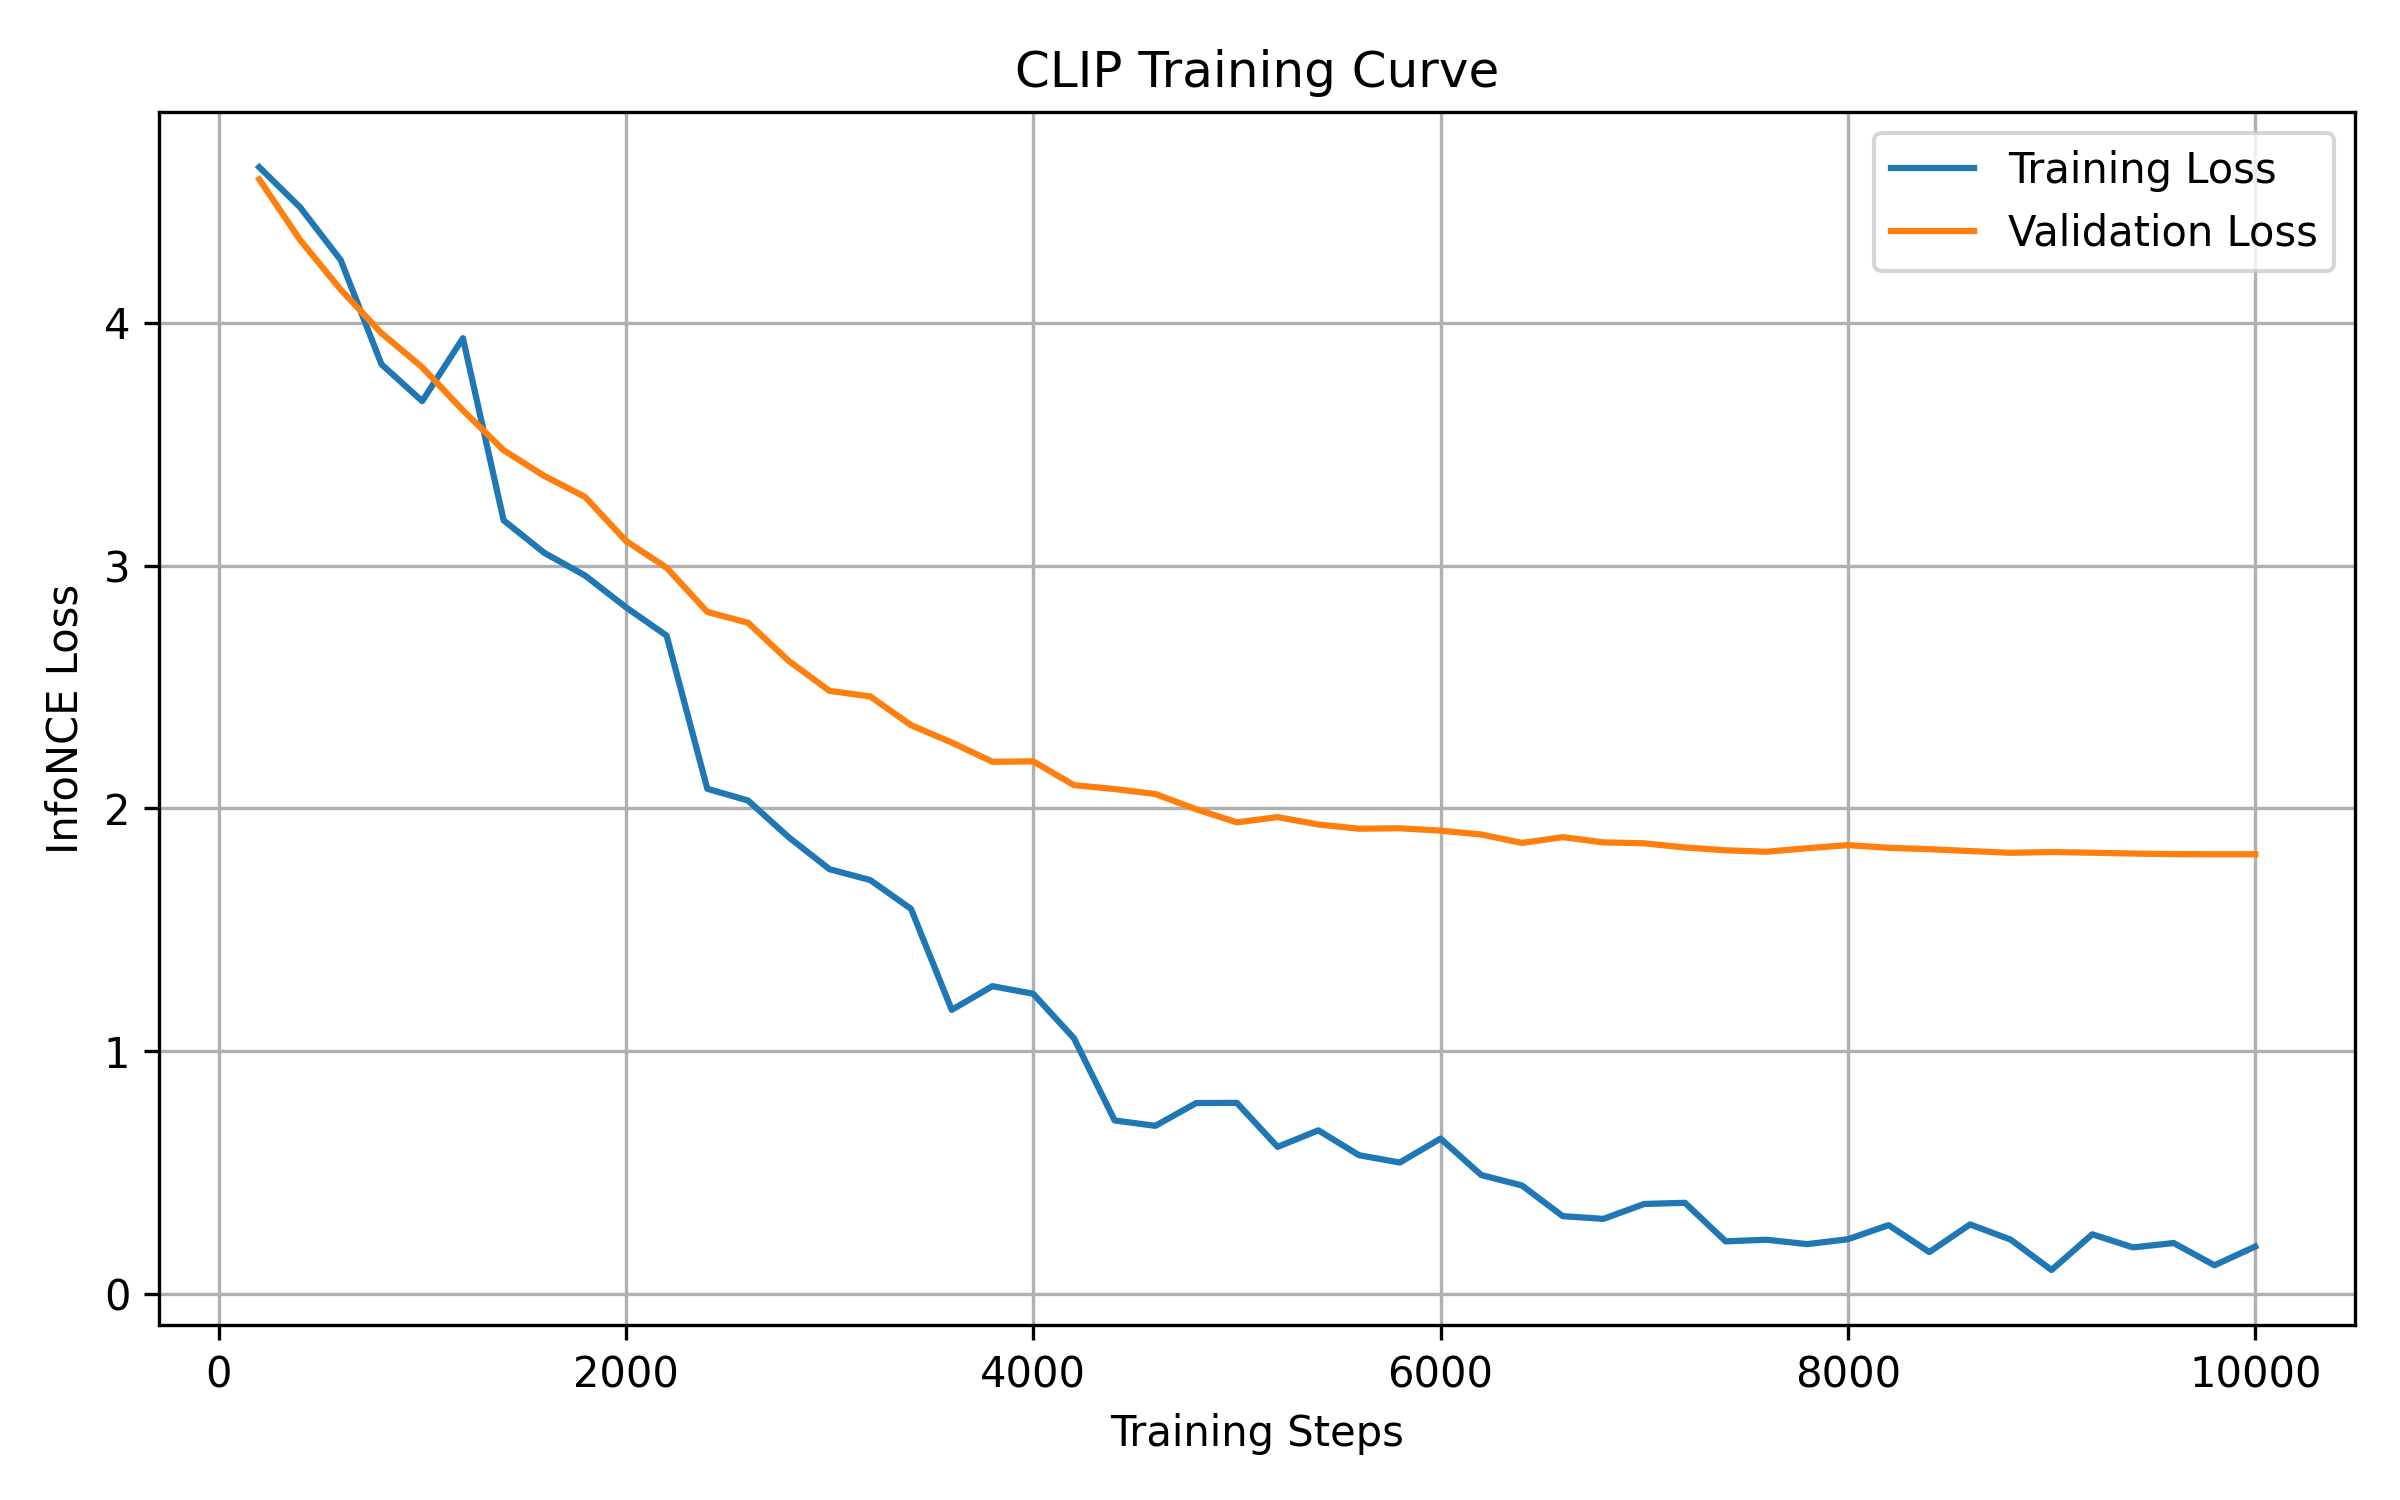

30)

The CLIP-style model was trained for **10,000 optimization steps** using the InfoNCE contrastive loss. The training loss decreased steadily from **4.64** at step 200 to **0.20** at the end of training, while the validation loss decreased from **4.59** to **1.81**. The rapid decrease during the initial training phase indicates that the model quickly learned meaningful image-text alignments, after which both losses improved more gradually.

The validation loss continued to improve until approximately **7,500–8,000 steps**. Beyond this point, the improvements became very small, suggesting that the model had largely converged. The validation loss converged to around **1.81**.

**Final Training Loss:** **0.1953**

**Final Validation Loss:** **1.8113**

**Approximate Convergence Step:** **7,500–8,000 training steps**

31)
## Retrieval Evaluation

The retrieval performance of the model was evaluated using **Recall@1, Recall@5, and Recall@10** for both image-to-text and text-to-image retrieval on the Flickr8k validation set.

| Retrieval Task | Recall@1 | Recall@5 | Recall@10 |
|:--------------|---------:|---------:|----------:|
| **Image → Text** | **20.68%** | **45.25%** | **56.75%** |
| **Text → Image** | **19.31%** | **42.47%** | **54.49%** |

### Discussion

The model performs best at **Recall@10**, where it achieves **56.75%** for image-to-text retrieval and **54.49%** for text-to-image retrieval. This means that in more than half of the queries, the correct match is found within the top 10 retrieved results.

As expected, **Recall@1** is the most challenging metric, with accuracies of **20.68%** and **19.31%** for the two retrieval tasks. Although the model does not always rank the correct match first, it is usually able to place it among the top few results.

Image-to-text retrieval performs slightly better than text-to-image retrieval across all three metrics, which is consistent with the expected behavior for a CLIP-style model.

32)
## Bugs Encountered and Debugging

This was probably the most time-consuming part of the project. Since the entire pipeline was built from scratch, I ran into quite a few issues before getting a stable implementation.

- I initially had incorrect batch dimensions while preparing the Flickr8k dataset, which caused tensor shape mismatch errors during training. Printing tensor shapes at every stage helped me identify and fix the issue.

- My first training loop did not exactly match the handbook, so I corrected the training hyperparameters and scheduler after comparing my implementation with the reference.

- I forgot to save the best model checkpoint to Google Drive. Although the script printed "Best model saved", the checkpoint was lost when the Colab runtime disconnected, so I had to retrain the model.

- During evaluation, I encountered model loading errors because the architecture used for evaluation did not match the one used during training. Using identical model parameters resolved the issue.

- While building the text-to-image search engine, I initially indexed every image-caption pair instead of unique images, leading to duplicate search results. Removing duplicate image entries fixed the retrieval system.

- The interactive search application also took a few attempts because my initial implementation stopped accepting new queries after displaying the retrieved images. I eventually redesigned it into a continuously usable search interface.

Most of these bugs were resolved by debugging one component at a time and verifying intermediate outputs instead of trying to fix the entire pipeline at once.

33)
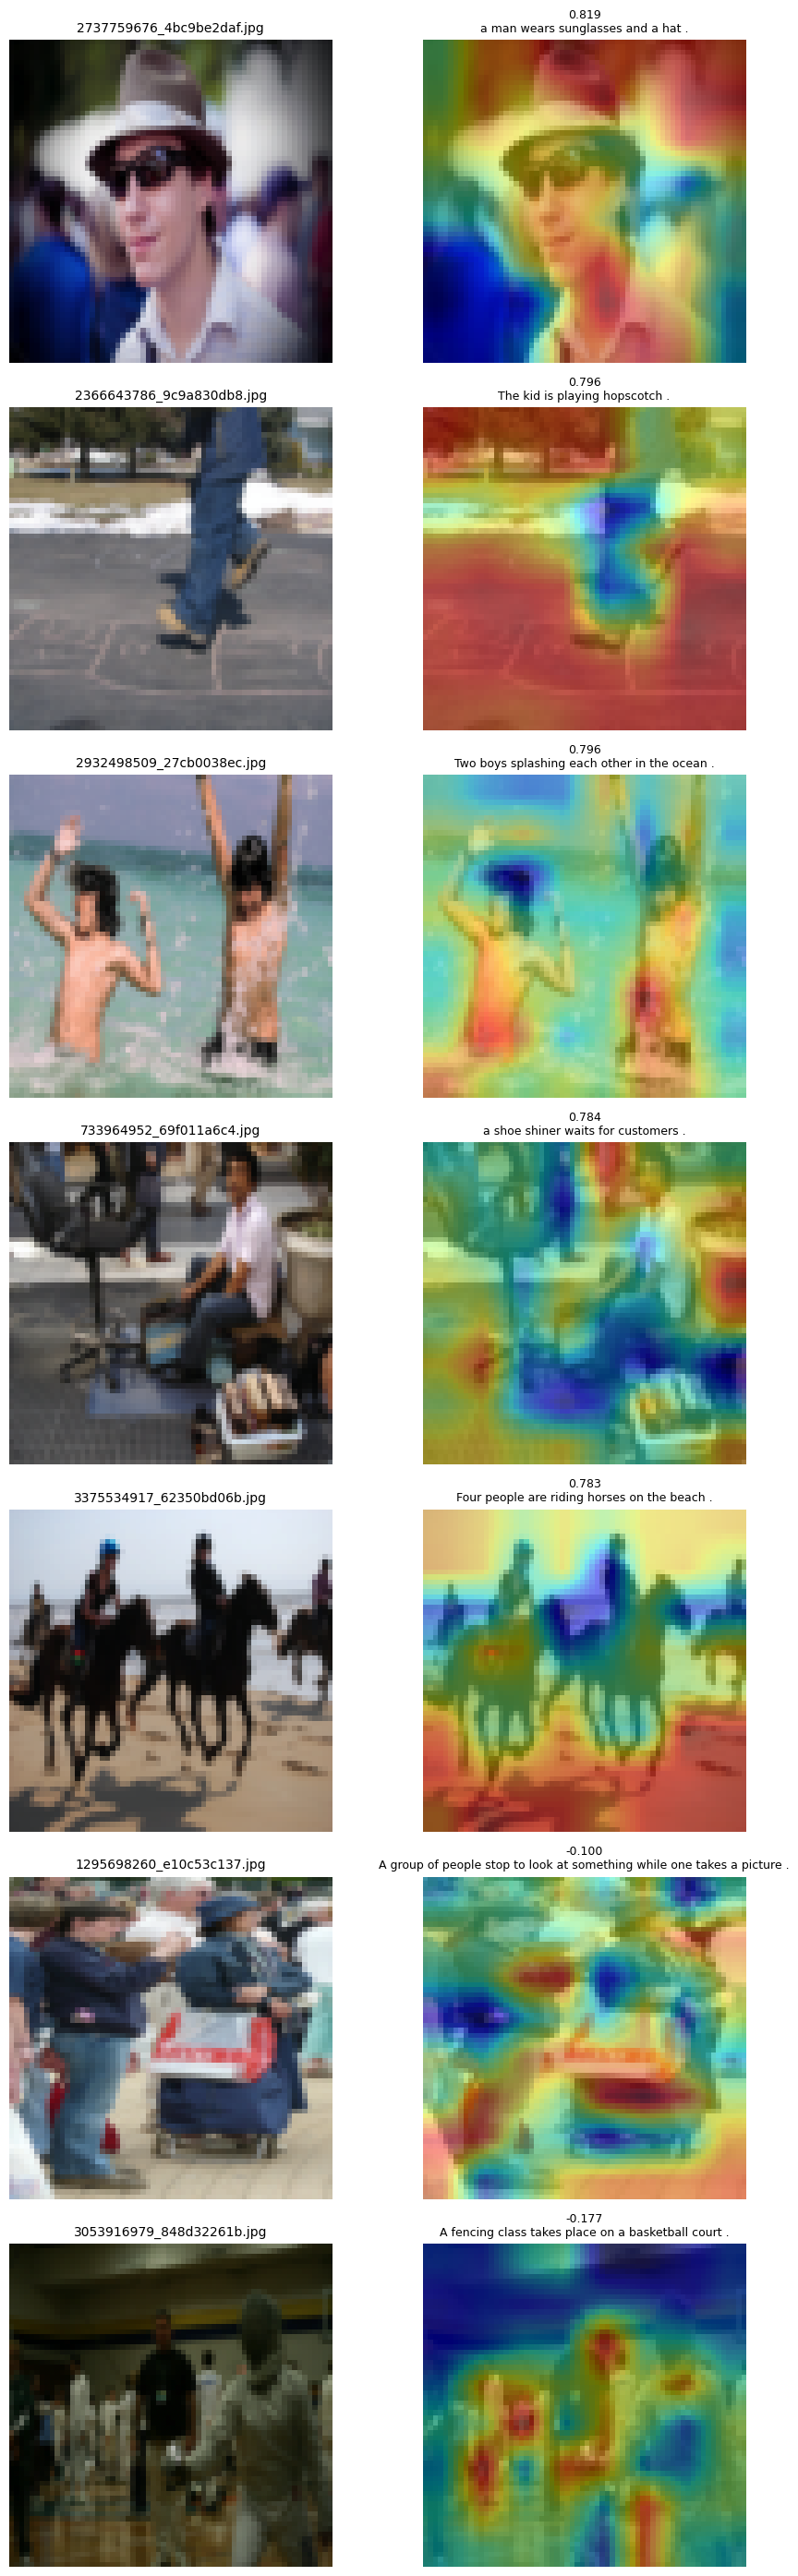

### Qualitative Analysis

The similarity maps generally show that the model focuses on the main subject of the image rather than the background. In the image of the man wearing a hat and sunglasses, the highest activations are around the face and hat, which makes sense because these are the key parts described by the caption.

The hopscotch example was particularly interesting. The model highlights not only the child but also the hopscotch grid, suggesting that it is making use of both the action and the surrounding context when matching the caption. I noticed a similar pattern in the shoe-shining image, where the strongest responses are around the people and the shoe-shining setup rather than the rest of the scene which includes the man himself.

In the image of the two boys splashing in the water, the model highlights both people instead of the water, suggesting that it has learned to prioritize the important objects mentioned in the caption.

The failure cases are also interesting. Instead of focusing on one clear region, the activations are spread across the image, making it harder for the model to associate the image with the correct caption. Most of these images contain multiple people or cluttered backgrounds, which likely makes the retrieval task more difficult.

34)
### Zero-Shot Classification

The model performed best on broad and visually distinctive classes such as **people**, **children**, and **dogs**. These classes were correctly identified in several examples, especially when the subject occupied a large portion of the image.

The model struggled more with images containing people performing specific actions or interacting with objects. In several cases, images of men were incorrectly classified as **horses** or **birds**, even though neither object was present. Since the model was trained for image-text retrieval rather than supervised classification, this is not entirely unexpected. During zero-shot inference, it simply chooses the class prompt with the highest similarity, even if none of the prompts is a particularly good match.

I believe these errors are mainly due to the limited training scale and the small set of class prompts rather than a lack of training examples. A larger model trained on a much more diverse dataset would likely learn more robust semantic representations and produce more reliable zero-shot predictions.

35)
## Applied Stretch Task – Text-to-Image Search Engine

For the applied stretch task, I implemented a **text-to-image search engine** using the trained CLIP-style model. The application precomputes image embeddings for the Flickr8k dataset and, given a natural language query, retrieves the top-5 most similar images based on cosine similarity. (Screenshots are attached below.)

This was probably my favourite part of the project because it felt like using a real application rather than just training a model.

One thing that surprised me was how well the model handled descriptive prompts such as **"sunset over water"** or **"a person riding a bicycle"**, even though these exact phrases were not necessarily seen during training. This showed me that the model had learned a shared embedding space between images and text instead of simply memorizing captions.

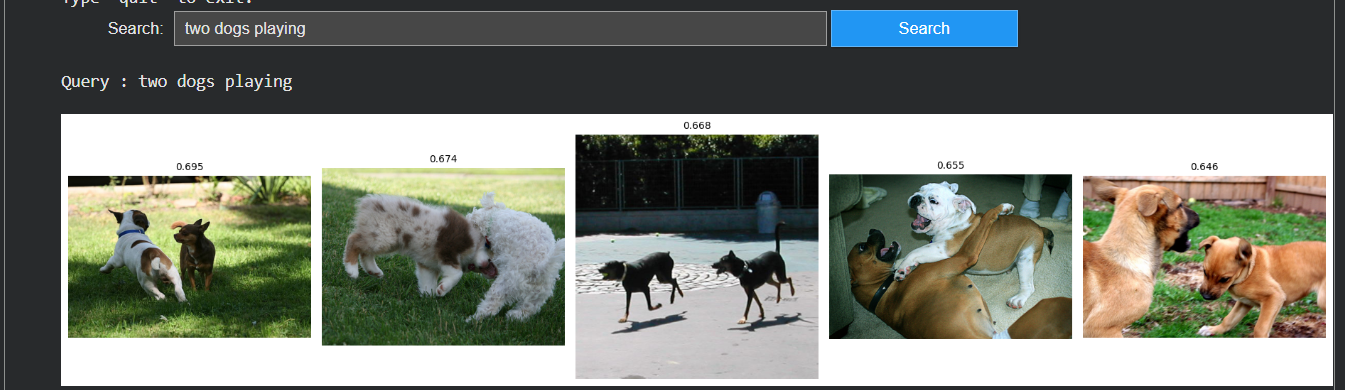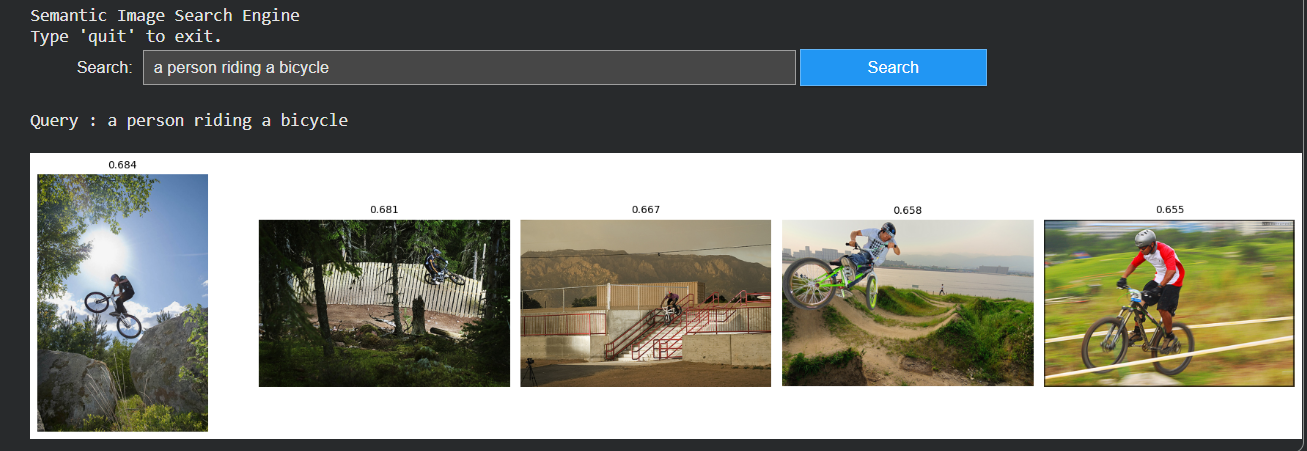

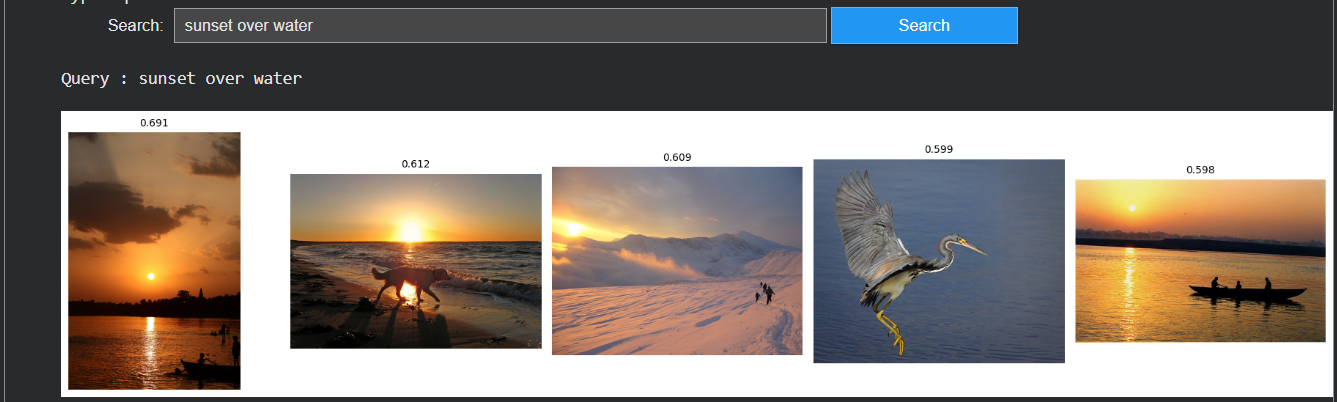

36)
If I had another week, I would repeat the training using **128×128 images** while keeping the rest of the architecture unchanged. A higher image resolution would preserve more visual details, which could help the model learn finer correspondences between images and captions. I would then compare the retrieval metrics and zero-shot classification performance to see whether the additional visual information leads to better multimodal alignment.